# Experiment 2: Email Spam Classification using Naïve Bayes and K-Nearest Neighbors (KNN)
**Student Name:** Naveenkumar  
**Register Number:** 3122247001038  

---
### Objective
To implement, evaluate, and compare Naïve Bayes variants (Gaussian, Multinomial, Bernoulli) and K-Nearest Neighbors (KNN) algorithms on the Spambase dataset for email spam classification, perform feature scaling, execute hyperparameter tuning via 5-fold cross-validation (`GridSearchCV` and `RandomizedSearchCV`), and analyze classification metrics, confusion matrices, ROC/PR curves, and computational efficiency.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import time

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve

# Load Spambase Dataset
df = pd.read_csv("spambase_csv.xls")

print("Dataset Overview:")
print("Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

# Features and Target split
X = df.drop("class", axis=1)
y = df["class"]

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Dataset Overview:
Shape: (4601, 58)
Missing Values: 0
Duplicate Rows: 391
Shape after dropping duplicates: (4210, 58)
Train shape: (3368, 57) Test shape: (842, 57)


## Section 1: Exploratory Data Analysis (EDA)

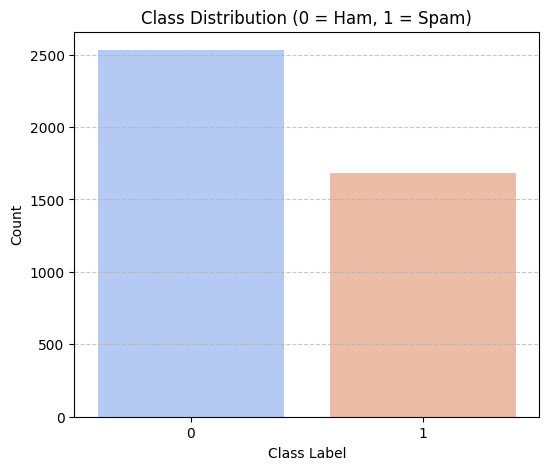

In [ ]:
plt.figure(figsize=(6, 5))
sns.countplot(x=y, hue=y, palette="coolwarm", legend=False)
plt.title("Class Distribution (0 = Ham, 1 = Spam)")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

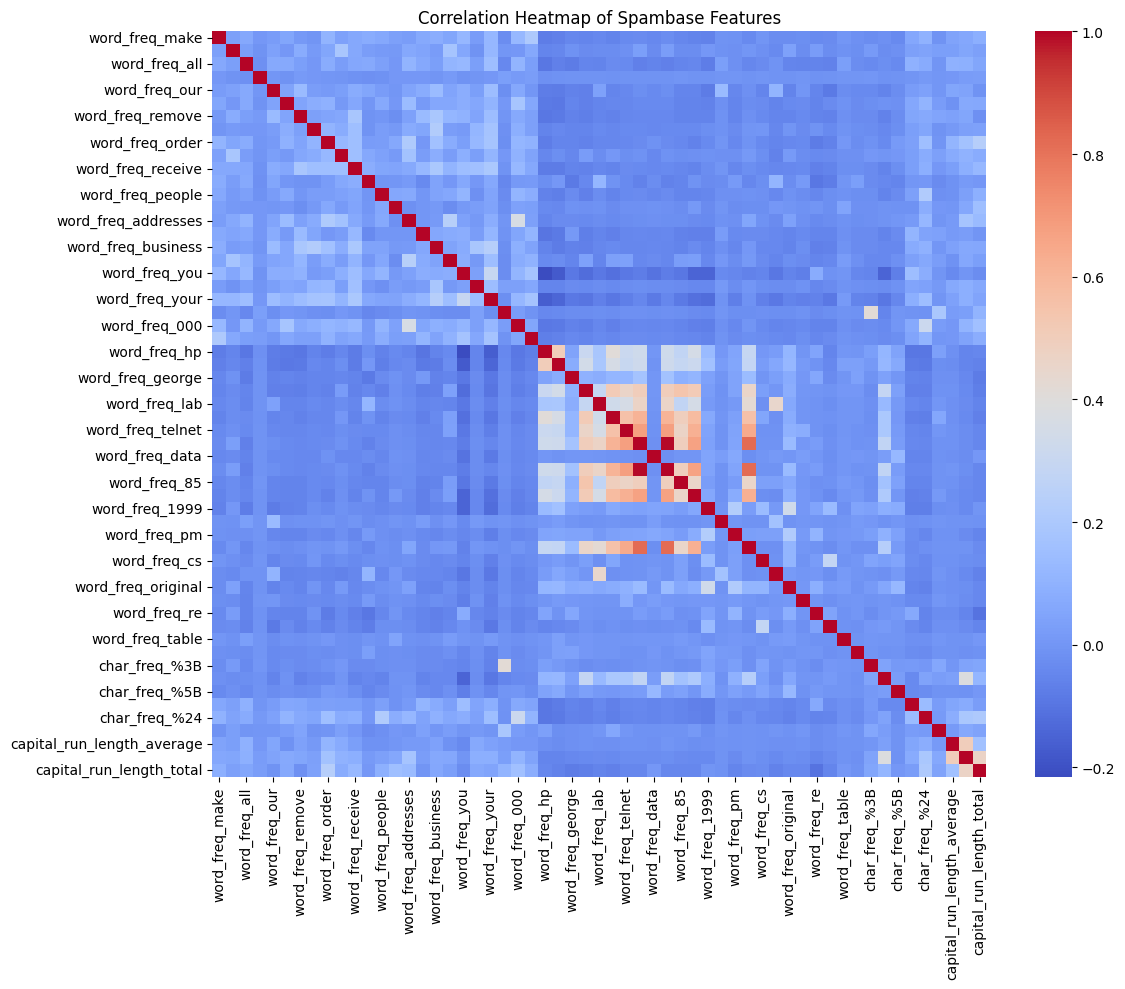

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(X.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Spambase Features")
plt.tight_layout()
plt.show()

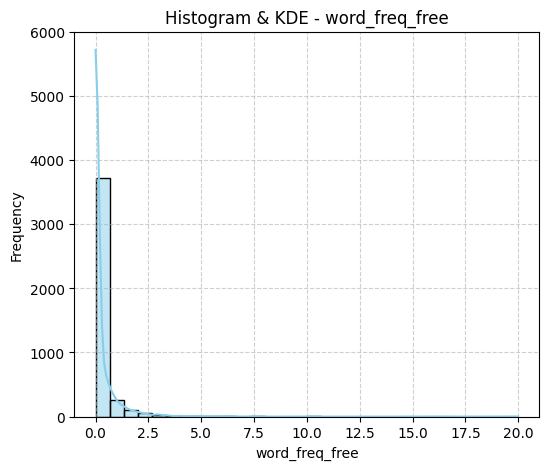

In [ ]:
plt.figure(figsize=(6, 5))
sns.histplot(df["word_freq_free"], kde=True, color="skyblue", bins=30)
plt.title("Histogram & KDE - word_freq_free")
plt.xlabel("word_freq_free")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

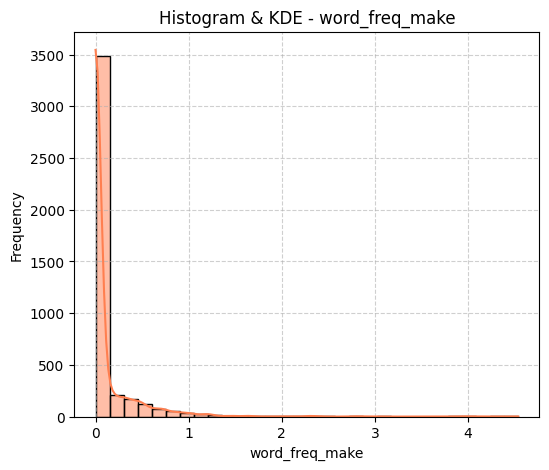

In [ ]:
plt.figure(figsize=(6, 5))
sns.histplot(df["word_freq_make"], kde=True, color="coral", bins=30)
plt.title("Histogram & KDE - word_freq_make")
plt.xlabel("word_freq_make")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

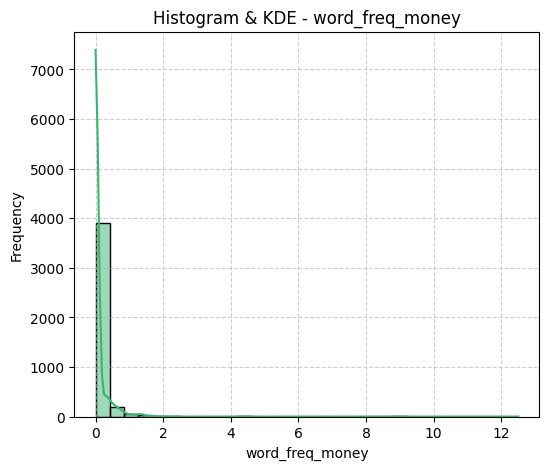

In [ ]:
plt.figure(figsize=(6, 5))
sns.histplot(df["word_freq_money"], kde=True, color="mediumseagreen", bins=30)
plt.title("Histogram & KDE - word_freq_money")
plt.xlabel("word_freq_money")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

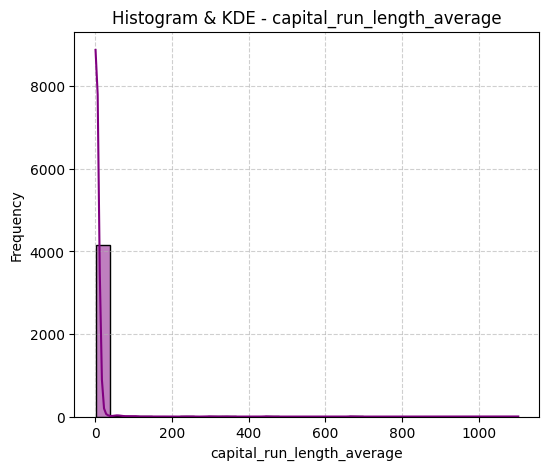

In [ ]:
plt.figure(figsize=(6, 5))
sns.histplot(df["capital_run_length_average"], kde=True, color="purple", bins=30)
plt.title("Histogram & KDE - capital_run_length_average")
plt.xlabel("capital_run_length_average")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

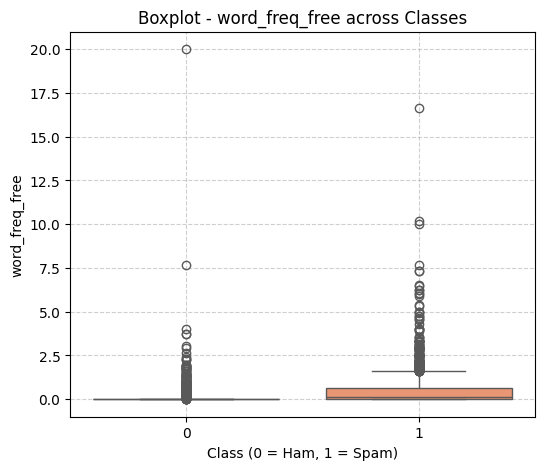

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(x=y, y=df["word_freq_free"], hue=y, palette="Set2", legend=False)
plt.title("Boxplot - word_freq_free across Classes")
plt.xlabel("Class (0 = Ham, 1 = Spam)")
plt.ylabel("word_freq_free")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

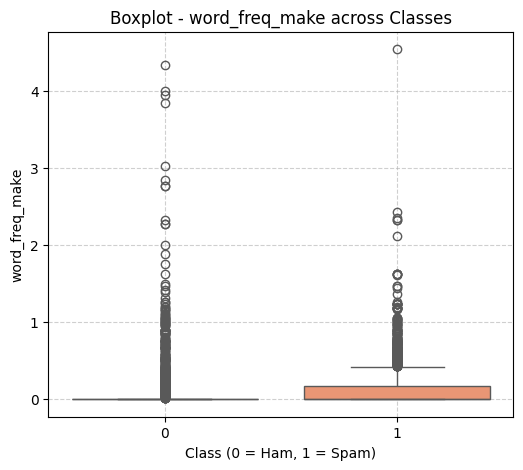

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(x=y, y=df["word_freq_make"], hue=y, palette="Set2", legend=False)
plt.title("Boxplot - word_freq_make across Classes")
plt.xlabel("Class (0 = Ham, 1 = Spam)")
plt.ylabel("word_freq_make")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

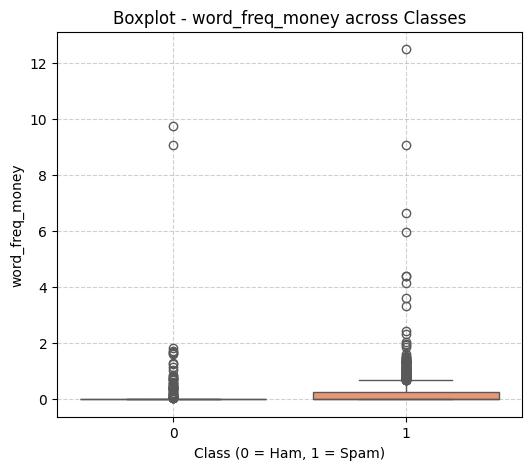

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(x=y, y=df["word_freq_money"], hue=y, palette="Set2", legend=False)
plt.title("Boxplot - word_freq_money across Classes")
plt.xlabel("Class (0 = Ham, 1 = Spam)")
plt.ylabel("word_freq_money")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

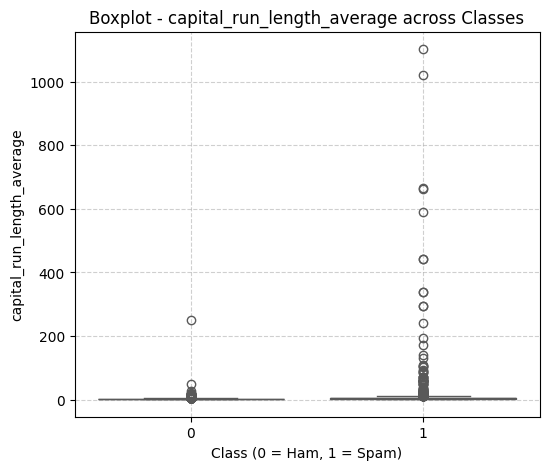

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(x=y, y=df["capital_run_length_average"], hue=y, palette="Set2", legend=False)
plt.title("Boxplot - capital_run_length_average across Classes")
plt.xlabel("Class (0 = Ham, 1 = Spam)")
plt.ylabel("capital_run_length_average")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Section 2: Model Training & Evaluation - Naïve Bayes Classifiers

In [ ]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
y_prob_gnb = gnb.predict_proba(X_test)[:, 1]

gaussian_accuracy = accuracy_score(y_test, y_pred_gnb)
print("=== Gaussian Naive Bayes ===")
print("Accuracy:", gaussian_accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred_gnb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gnb))

=== Gaussian Naive Bayes ===
Accuracy: 0.8467933491686461

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.76      0.85       483
           1       0.75      0.97      0.84       359

    accuracy                           0.85       842
   macro avg       0.86      0.86      0.85       842
weighted avg       0.88      0.85      0.85       842

Confusion Matrix:
 [[365 118]
 [ 11 348]]


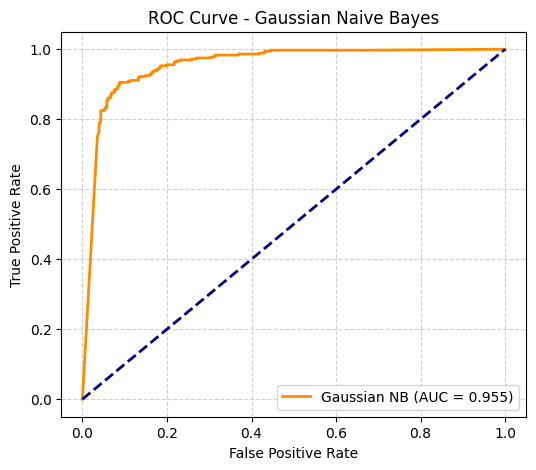

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob_gnb)
auc_gnb = roc_auc_score(y_test, y_prob_gnb)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"Gaussian NB (AUC = {auc_gnb:.3f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gaussian Naive Bayes")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

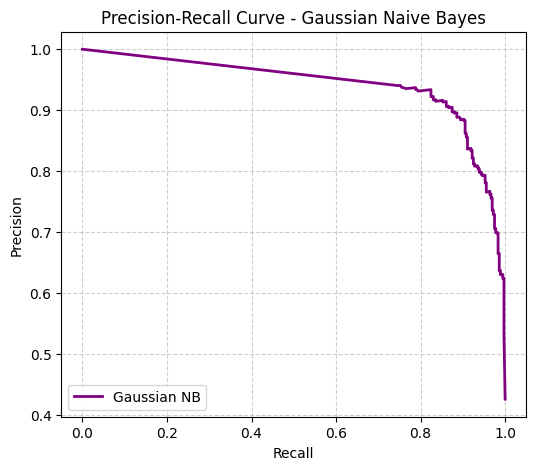

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_prob_gnb)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='purple', lw=2, label="Gaussian NB")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Gaussian Naive Bayes")
plt.legend(loc="lower left")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred_mnb = mnb.predict(X_test)
y_prob_mnb = mnb.predict_proba(X_test)[:, 1]

multinomial_accuracy = accuracy_score(y_test, y_pred_mnb)
print("=== Multinomial Naive Bayes ===")
print("Accuracy:", multinomial_accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred_mnb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_mnb))

=== Multinomial Naive Bayes ===
Accuracy: 0.8040380047505938

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.83       483
           1       0.79      0.74      0.76       359

    accuracy                           0.80       842
   macro avg       0.80      0.80      0.80       842
weighted avg       0.80      0.80      0.80       842

Confusion Matrix:
 [[411  72]
 [ 93 266]]


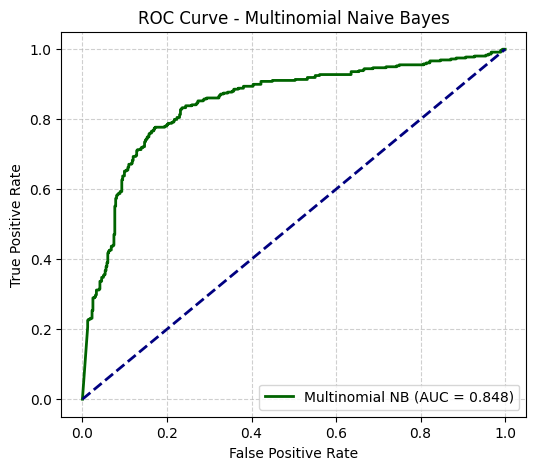

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob_mnb)
auc_mnb = roc_auc_score(y_test, y_prob_mnb)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkgreen', lw=2, label=f"Multinomial NB (AUC = {auc_mnb:.3f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Multinomial Naive Bayes")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

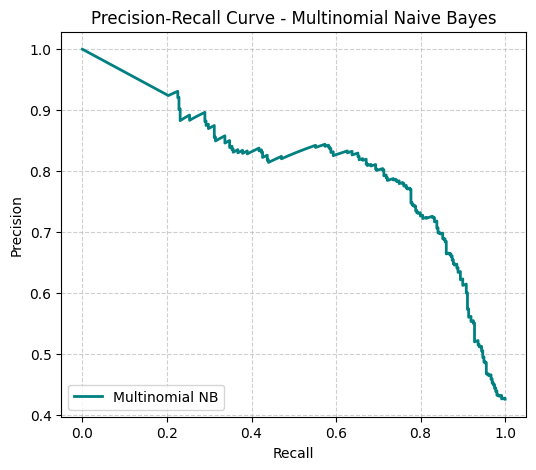

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_prob_mnb)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='teal', lw=2, label="Multinomial NB")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Multinomial Naive Bayes")
plt.legend(loc="lower left")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
bnb = BernoulliNB()
bnb.fit(X_train, y_train)
y_pred_bnb = bnb.predict(X_test)
y_prob_bnb = bnb.predict_proba(X_test)[:, 1]

bernoulli_accuracy = accuracy_score(y_test, y_pred_bnb)
print("=== Bernoulli Naive Bayes ===")
print("Accuracy:", bernoulli_accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred_bnb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_bnb))

=== Bernoulli Naive Bayes ===
Accuracy: 0.8812351543942993

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.93      0.90       483
           1       0.90      0.82      0.85       359

    accuracy                           0.88       842
   macro avg       0.88      0.87      0.88       842
weighted avg       0.88      0.88      0.88       842

Confusion Matrix:
 [[449  34]
 [ 66 293]]


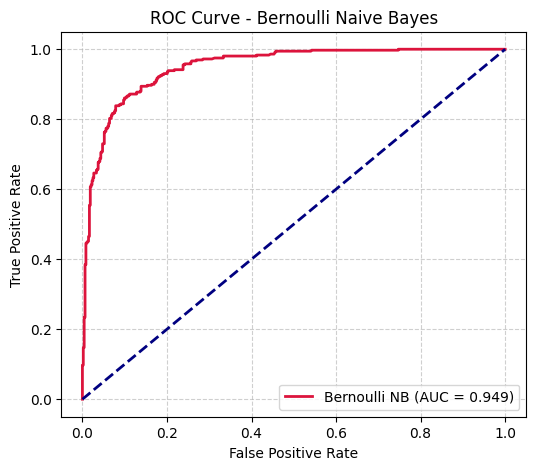

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob_bnb)
auc_bnb = roc_auc_score(y_test, y_prob_bnb)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='crimson', lw=2, label=f"Bernoulli NB (AUC = {auc_bnb:.3f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Bernoulli Naive Bayes")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

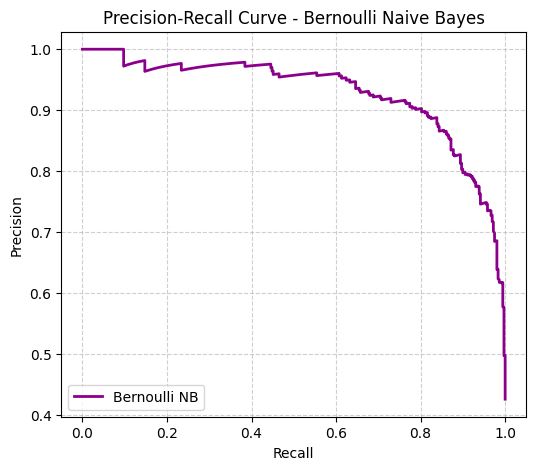

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_prob_bnb)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='darkmagenta', lw=2, label="Bernoulli NB")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Bernoulli Naive Bayes")
plt.legend(loc="lower left")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Section 3: Model Training & Evaluation - K-Nearest Neighbors (KNN)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

knn_accuracy = accuracy_score(y_test, y_pred_knn)
print("=== K-Nearest Neighbors (k=5, Scaled) ===")
print("Accuracy:", knn_accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

=== K-Nearest Neighbors (k=5, Scaled) ===
Accuracy: 0.8836104513064132

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.90       483
           1       0.89      0.82      0.86       359

    accuracy                           0.88       842
   macro avg       0.89      0.88      0.88       842
weighted avg       0.88      0.88      0.88       842

Confusion Matrix:
 [[448  35]
 [ 63 296]]


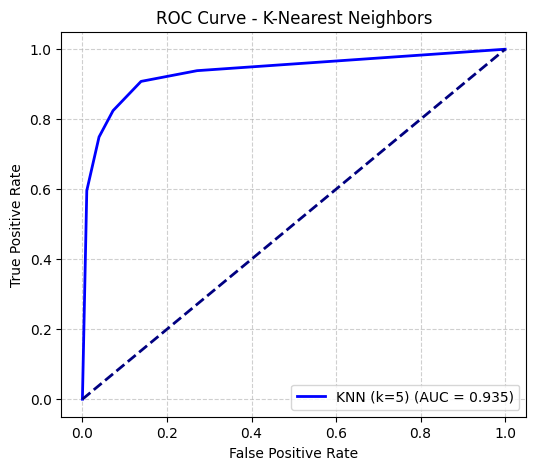

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"KNN (k=5) (AUC = {auc_knn:.3f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - K-Nearest Neighbors")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

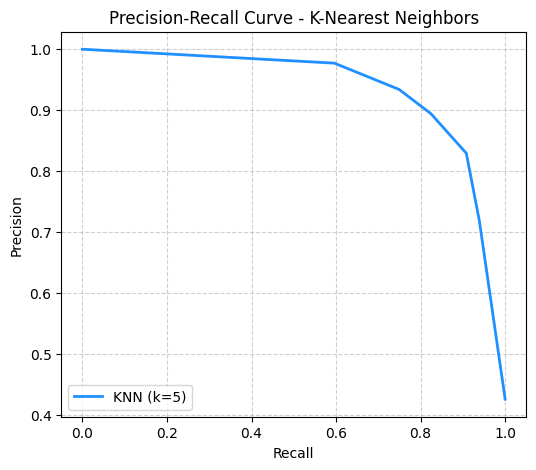

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_prob_knn)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='dodgerblue', lw=2, label="KNN (k=5)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - K-Nearest Neighbors")
plt.legend(loc="lower left")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Section 4: Hyperparameter Tuning & Sensitivity Analysis

k =  1 | Test Accuracy = 0.8907
k =  3 | Test Accuracy = 0.8848
k =  4 | Test Accuracy = 0.8800
k =  5 | Test Accuracy = 0.8836
k =  7 | Test Accuracy = 0.8872
k =  9 | Test Accuracy = 0.8931
k = 11 | Test Accuracy = 0.8907


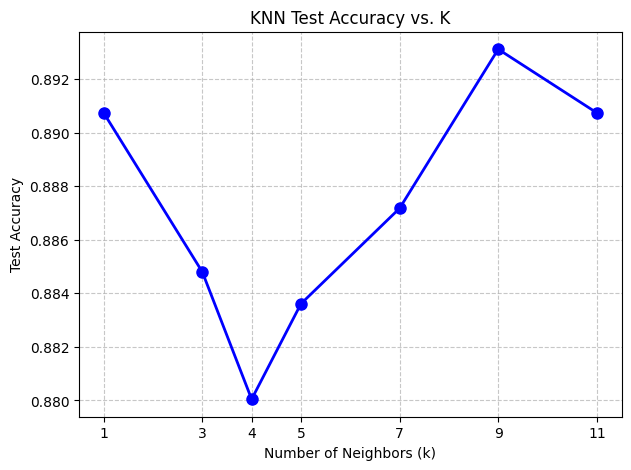

In [ ]:
k_try = [1, 3, 4, 5, 7, 9, 11]
k_values = []
accuracy_values = []

for k in k_try:
    model_k = KNeighborsClassifier(n_neighbors=k)
    model_k.fit(X_train_scaled, y_train)
    y_pred_k = model_k.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_k)
    k_values.append(k)
    accuracy_values.append(acc)
    print(f"k = {k:2d} | Test Accuracy = {acc:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(k_values, accuracy_values, marker='o', color='b', linestyle='-', linewidth=2, markersize=8)
plt.title("KNN Test Accuracy vs. K")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Test Accuracy")
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Best Parameters (GridSearchCV): {'n_neighbors': 5}
Best CV Accuracy (GridSearchCV): 0.9029126855701695


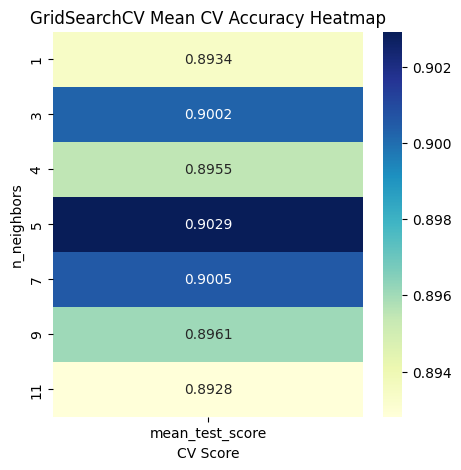

In [ ]:
param_grid = {"n_neighbors": [1, 3, 4, 5, 7, 9, 11]}
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring="accuracy")
grid_search.fit(X_train_scaled, y_train)

print("Best Parameters (GridSearchCV):", grid_search.best_params_)
print("Best CV Accuracy (GridSearchCV):", grid_search.best_score_)

grid_results = pd.DataFrame(grid_search.cv_results_)
heatmap_data = grid_results.pivot_table(values="mean_test_score", index="param_n_neighbors")

plt.figure(figsize=(5, 5))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt=".4f", cbar=True)
plt.title("GridSearchCV Mean CV Accuracy Heatmap")
plt.xlabel("CV Score")
plt.ylabel("n_neighbors")
plt.show()

Best Parameters (RandomizedSearchCV): {'n_neighbors': 7}
Best CV Accuracy (RandomizedSearchCV): 0.9005383574146497


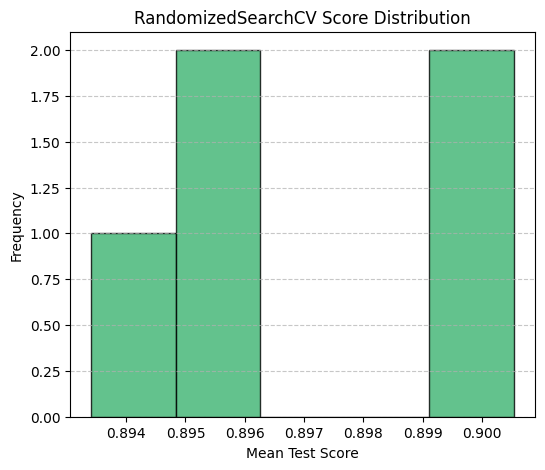

In [ ]:
random_search = RandomizedSearchCV(KNeighborsClassifier(), param_distributions=param_grid, n_iter=5, cv=5, scoring="accuracy", random_state=42)
random_search.fit(X_train_scaled, y_train)

print("Best Parameters (RandomizedSearchCV):", random_search.best_params_)
print("Best CV Accuracy (RandomizedSearchCV):", random_search.best_score_)

random_results = pd.DataFrame(random_search.cv_results_)

plt.figure(figsize=(6, 5))
plt.hist(random_results["mean_test_score"], bins=5, color='mediumseagreen', edgecolor='black', alpha=0.8)
plt.title("RandomizedSearchCV Score Distribution")
plt.xlabel("Mean Test Score")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Section 5: Distance Search Algorithms & Timing Benchmark

In [ ]:
print("="*50)
print("KDTree Neighbor Search")
print("="*50)
t0 = time.time()
kd_mod = KNeighborsClassifier(n_neighbors=5, algorithm="kd_tree")
kd_mod.fit(X_train_scaled, y_train)
kd_train = time.time() - t0

t0 = time.time()
y_pred_kd = kd_mod.predict(X_test_scaled)
kd_predict = time.time() - t0

print(f"KDTree Test Accuracy: {accuracy_score(y_test, y_pred_kd):.4f}")
print(f"KDTree Training Time: {kd_train:.6f} s | Prediction Time: {kd_predict:.6f} s")

print("\n" + "="*50)
print("BallTree Neighbor Search")
print("="*50)
t0 = time.time()
ball_mod = KNeighborsClassifier(n_neighbors=5, algorithm="ball_tree")
ball_mod.fit(X_train_scaled, y_train)
ball_train = time.time() - t0

t0 = time.time()
y_pred_ball = ball_mod.predict(X_test_scaled)
ball_predict = time.time() - t0

print(f"BallTree Test Accuracy: {accuracy_score(y_test, y_pred_ball):.4f}")
print(f"BallTree Training Time: {ball_train:.6f} s | Prediction Time: {ball_predict:.6f} s")

KDTree Neighbor Search
KDTree Test Accuracy: 0.8836
KDTree Training Time: 0.020165 s | Prediction Time: 0.158677 s

BallTree Neighbor Search
BallTree Test Accuracy: 0.8836
BallTree Training Time: 0.011869 s | Prediction Time: 0.158218 s


## Section 6: Cross Validation & Model Performance Summary

In [ ]:
cv_gnb = cross_val_score(GaussianNB(), X, y, cv=5, scoring="accuracy").mean()
cv_mnb = cross_val_score(MultinomialNB(), X, y, cv=5, scoring="accuracy").mean()
cv_bnb = cross_val_score(BernoulliNB(), X, y, cv=5, scoring="accuracy").mean()

X_scaled_full = scaler.fit_transform(X)
cv_knn = cross_val_score(KNeighborsClassifier(n_neighbors=5), X_scaled_full, y, cv=5, scoring="accuracy").mean()

print("5-Fold Cross Validation Mean Accuracies:")
print(f"Gaussian NB    : {cv_gnb:.4f}")
print(f"Multinomial NB : {cv_mnb:.4f}")
print(f"Bernoulli NB   : {cv_bnb:.4f}")
print(f"KNN (k=5)      : {cv_knn:.4f}")

5-Fold Cross Validation Mean Accuracies:
Gaussian NB    : 0.8325
Multinomial NB : 0.7862
Bernoulli NB   : 0.8827
KNN (k=5)      : 0.8829


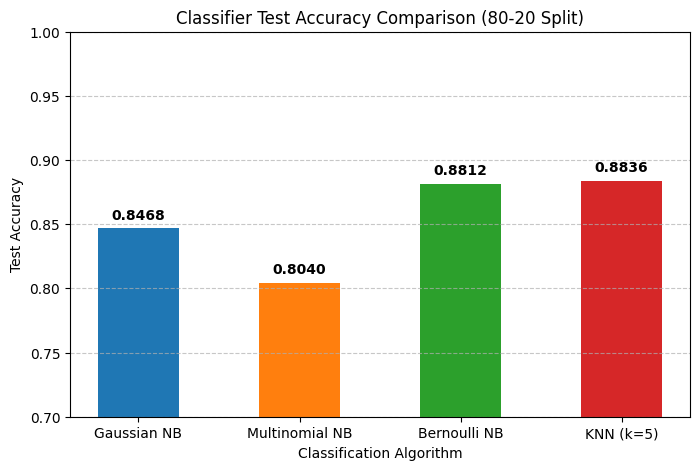

In [ ]:
models = ["Gaussian NB", "Multinomial NB", "Bernoulli NB", "KNN (k=5)"]
accuracies = [gaussian_accuracy, multinomial_accuracy, bernoulli_accuracy, knn_accuracy]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], width=0.5)
plt.title("Classifier Test Accuracy Comparison (80-20 Split)")
plt.xlabel("Classification Algorithm")
plt.ylabel("Test Accuracy")
plt.ylim(0.70, 1.00)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

plt.show()

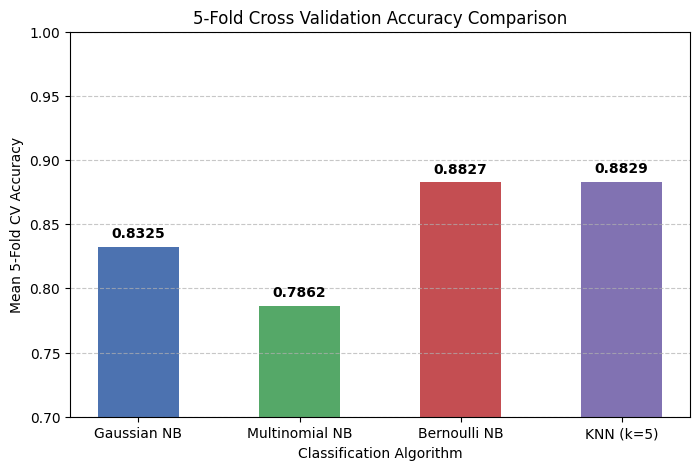

In [ ]:
cv_models = ["Gaussian NB", "Multinomial NB", "Bernoulli NB", "KNN (k=5)"]
cv_scores = [cv_gnb, cv_mnb, cv_bnb, cv_knn]

plt.figure(figsize=(8, 5))
bars = plt.bar(cv_models, cv_scores, color=['#4c72b0', '#55a868', '#c44e52', '#8172b2'], width=0.5)
plt.title("5-Fold Cross Validation Accuracy Comparison")
plt.xlabel("Classification Algorithm")
plt.ylabel("Mean 5-Fold CV Accuracy")
plt.ylim(0.70, 1.00)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

plt.show()